# Préliminaire analysis -  LOLO



## 💡 Idée de projet
How mice perceive animal vs plant images: a combined analysis of brain activity, eye movements, and behavior

## 🔹 Pré-analyses

1. **Réponses neuronales (PSTH & population Exc/Inh)**

   * PSTH montre que l’activité dans VISal (pas uniquement) est plus élevée avec images animal.
   * Excitateur vs Inhibiteur .

2. **Réponses oculaires (eye-tracking)**

   * Heatmap 2D pupille → regard plus centré pour les animaux.
   * PCA (eye\_area, pupil\_area, blink\_rate) → catégories distinctes déjà séparables par les yeux.

3. **Comportement locomoteur (running)**

   * Running speed diminue après apparition d’un animal → possible signe de surprise/attention.
   * Corrélation speed–eye → tester si ce ralentissement est couplé aux changements de regard.



➡️ Cela suggère que les animaux sont perçus comme plus **saillants et comportementalement pertinents** que les végétaux, et que cette saillance est visible à plusieurs niveaux du cerveau et du comportement.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import Data.NWB_reader_functions as nwbreader

In [2]:

nwbfile = r"Data/ecephys_session_1044016459.nwb"

In [3]:
unit_table = nwbreader.get_unit_table(nwbfile)
trial_table = nwbreader.get_trial_table(nwbfile)
metadata = nwbreader.get_session_metadata(nwbfile)
electrodes = nwbreader.get_electrode_table(nwbfile)
unit_table = unit_table.merge(
    electrodes,
    left_on="peak_channel_id",
    right_index=True,
    suffixes=("_unit", "_electrode")
)

In [4]:
print("-----UNIT TABLE-----")
print(unit_table.columns)
display(unit_table.sample(2))

print("-----TRIAL TABLE-----")
print(trial_table.columns)
display(trial_table.sample(7))

print("-----METADATA-----")
display(metadata)

-----UNIT TABLE-----
Index(['PT_ratio', 'amplitude', 'amplitude_cutoff', 'cluster_id',
       'cumulative_drift', 'd_prime', 'firing_rate', 'isi_violations',
       'isolation_distance', 'l_ratio', 'local_index', 'max_drift',
       'nn_hit_rate', 'nn_miss_rate', 'peak_channel_id', 'presence_ratio',
       'quality', 'recovery_slope', 'repolarization_slope', 'silhouette_score',
       'snr', 'spread', 'velocity_above', 'velocity_below',
       'waveform_duration', 'spike_times', 'spike_amplitudes', 'waveform_mean',
       'location', 'group', 'group_name', 'probe_vertical_position',
       'probe_horizontal_position', 'probe_id', 'probe_channel_number',
       'valid_data', 'x', 'y', 'z', 'imp', 'filtering'],
      dtype='object')


,PT_ratio,amplitude,amplitude_cutoff,cluster_id,cumulative_drift,d_prime,firing_rate,isi_violations,isolation_distance,l_ratio,...,probe_vertical_position,probe_horizontal_position,probe_id,probe_channel_number,valid_data,x,y,z,imp,filtering
id,,,,,,,,,,,,,,,,,,,,,
1163285456,0.062963,112.665930,0.500000,112,1098.01,4.246061,0.586554,1.328728,34.226410,0.016488,...,800,27,1160283386,79,True,0.0,0.0,0.0,NaN,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...
1163285201,0.021509,44.896702,0.387316,311,904.49,1.770682,3.780258,0.111971,32.946608,0.108077,...,3020,11,1160283385,301,True,0.0,0.0,0.0,NaN,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...


-----TRIAL TABLE-----
Index(['start_time', 'stop_time', 'initial_image_name', 'change_image_name',
       'is_change', 'change_time_no_display_delay', 'go', 'catch',
       'lick_times', 'response_time', 'reward_time', 'reward_volume', 'hit',
       'false_alarm', 'miss', 'correct_reject', 'aborted', 'auto_rewarded',
       'change_frame', 'trial_length'],
      dtype='object')


,start_time,stop_time,initial_image_name,change_image_name,is_change,change_time_no_display_delay,go,catch,lick_times,response_time,reward_time,reward_volume,hit,false_alarm,miss,correct_reject,aborted,auto_rewarded,change_frame,trial_length
id,,,,,,,,,,,,,,,,,,,,
639,3106.70897,3114.73258,im114_r,im034_r,True,3110.46267,True,False,"[3112.76371, 3112.9141, 3113.03059]",3112.76371,NaN,0.0,False,False,True,False,False,False,184959,8.02361
69,325.69919,328.50174,im005_r,im005_r,False,NaN,False,False,"[327.5842, 327.68387, 327.88406, 327.95086, 32...",NaN,NaN,0.0,False,False,False,False,True,False,-99,2.80255
676,3347.71045,3351.26381,im104_r,im104_r,False,NaN,False,False,[3350.94657],NaN,NaN,0.0,False,False,False,False,True,False,-99,3.55336
100,461.56303,462.64724,im087_r,im087_r,False,NaN,False,False,"[462.01348, 462.14662, 462.21306, 462.32984]",NaN,NaN,0.0,False,False,False,False,True,False,-99,1.08421
265,1231.15705,1238.42991,im114_r,im111_r,True,1234.15983,True,False,[],NaN,NaN,0.0,False,False,True,False,False,False,72475,7.27286
701,3479.83765,3487.87814,im087_r,im083_r,True,3483.59145,True,False,[],NaN,NaN,0.0,False,False,True,False,False,False,207328,8.04049
460,2333.36225,2337.44913,im024_r,im024_r,False,NaN,False,False,"[2336.81535, 2336.91488, 2337.06505, 2337.13177]",NaN,NaN,0.0,False,False,False,False,True,False,-99,4.08688


-----METADATA-----


{'metadata': metadata abc.BehaviorMetadata at 0x6074069440
 Fields:
   behavior_session_id: 1044048872
   behavior_session_uuid: 576aa8ad-aa9e-4587-9313-ceb84ce8c57b
   equipment_name: NP.1
   project_code: Not Available
   session_type: EPHYS_1_images_H_5uL_reward
   stimulus_frame_rate: 60.0,
 'task_parameters': task_parameters abc.BehaviorTaskParameters at 0x6079021696
 Fields:
   auto_reward_volume: 0.005
   blank_duration_sec: ['0.5' '0.5']
   n_stimulus_frames: 69360
   omitted_flash_fraction: 0.05
   response_window_sec: ['0.15' '0.75']
   reward_volume: 0.005
   session_type: EPHYS_1_images_H_5uL_reward
   stimulus: images
   stimulus_distribution: geometric
   stimulus_duration_sec: 0.25
   stimulus_name: Natural_Images_Lum_Matched_set_ophys_H_2019
   task: change detection}

In [5]:
unit_table.value_counts('location')

location
grey     1574
VISp      168
VISl      158
VISal     125
VISpm     120
VISam     117
VISrl      86
root       17
Name: count, dtype: int64

## IMAGE CHANGE

Now we'll grab spike times and calculate the change response for 'good' units in V1. Note that how you filter units will depend on your analysis. Consult the [unit metrics notebook](https://allensdk.readthedocs.io/en/latest/_static/examples/nb/visual_behavior_neuropixels_quality_metrics.html)  for more details.

### I. Good units

In [85]:
#first let's sort our units by depth
unit_table = unit_table.sort_values('probe_vertical_position', ascending=False)

#now we'll filter them
good_unit_filter_1 = ((unit_table['snr']>1)&
                    (unit_table['isi_violations']<1)&
                    (unit_table['firing_rate']>0.1) &
                    (unit_table['location'].isin(["VISal"])))


good_unit_filter_2 = ((unit_table['quality'] == 'good') &
                       (unit_table['presence_ratio'] > 0.85) &
                       (unit_table['d_prime'] > 2)&
                        (unit_table['location'].str.startswith("VIS")))


good_units = unit_table.loc[good_unit_filter_1]
print(len(good_units))
spike_times = unit_table['spike_times']


97


We can get the times when the image changes occurred from the stimulus presentations table. For now, we'll only take the image changes shown during the active behavior block

### II. Other data used

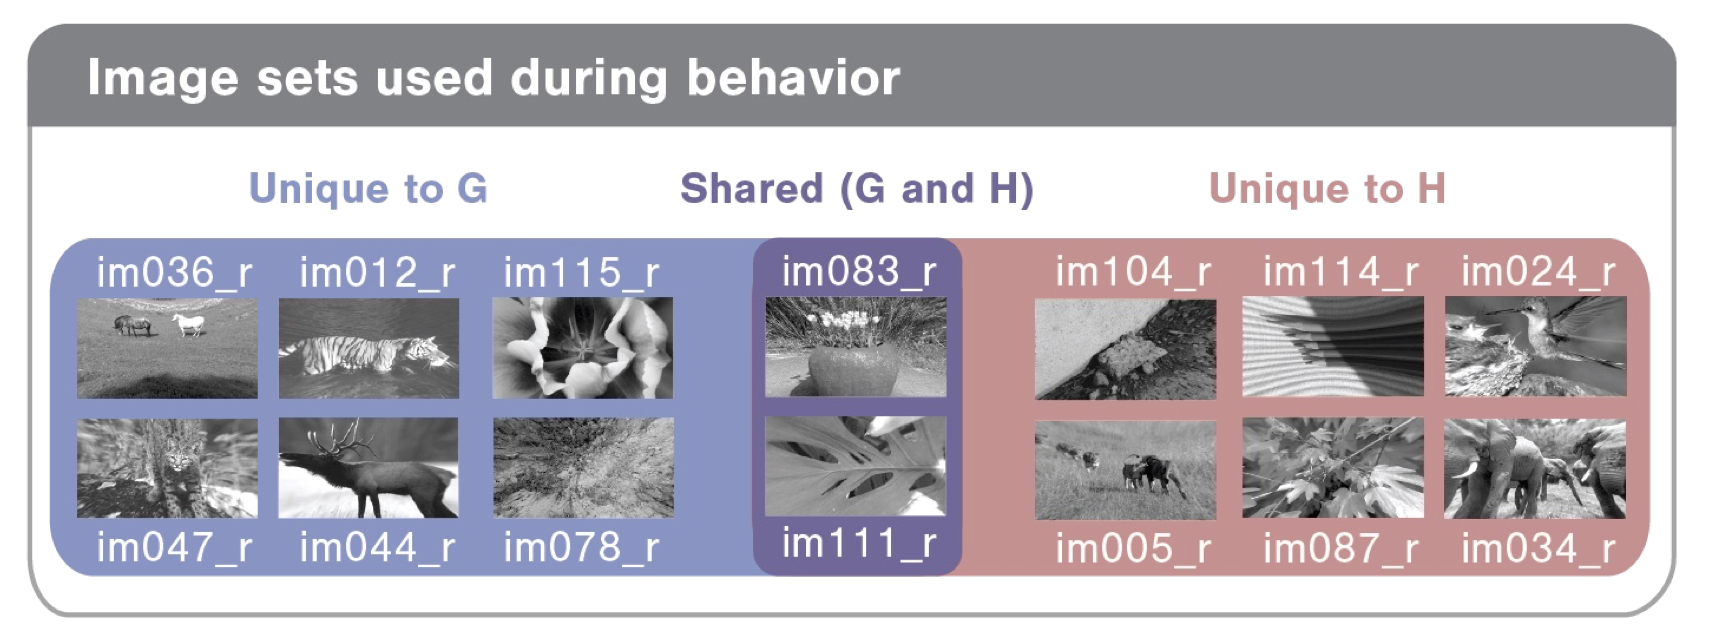

In [86]:
nat_images, spont, gabor, flashes = nwbreader.get_all_stim_presentations(nwbfile)
nat_images.head()


,start_time,stop_time,stimulus_block,image_name,duration,start_frame,end_frame,is_change,is_image_novel,omitted,flashes_since_change,trials_id,is_sham_change,active,rewarded,stimulus_name,stimulus_index,tags,timeseries
id,,,,,,,,,,,,,,,,,,,
0,26.227410,26.477618,0,im104_r,0.250208,60,75,0.0,1.0,0.0,0,0,False,True,0.0,Natural_Images_Lum_Matched_set_ophys_H_2019,-99,[stimulus_time_interval],"[(63, 15, timestamps pynwb.base.TimeSeries at ..."
1,26.978033,27.228241,0,im104_r,0.250208,105,120,0.0,1.0,0.0,1,0,False,True,0.0,Natural_Images_Lum_Matched_set_ophys_H_2019,-99,[stimulus_time_interval],"[(108, 15, timestamps pynwb.base.TimeSeries at..."
2,27.728660,27.978870,0,im104_r,0.250210,150,165,0.0,1.0,0.0,2,1,False,True,0.0,Natural_Images_Lum_Matched_set_ophys_H_2019,-99,[stimulus_time_interval],"[(153, 15, timestamps pynwb.base.TimeSeries at..."
3,28.479278,28.729475,0,im104_r,0.250198,195,210,0.0,1.0,0.0,3,1,False,True,0.0,Natural_Images_Lum_Matched_set_ophys_H_2019,-99,[stimulus_time_interval],"[(198, 15, timestamps pynwb.base.TimeSeries at..."
4,29.229871,29.480090,0,im104_r,0.250220,240,255,0.0,1.0,0.0,4,1,False,True,0.0,Natural_Images_Lum_Matched_set_ophys_H_2019,-99,[stimulus_time_interval],"[(243, 15, timestamps pynwb.base.TimeSeries at..."


In [87]:
# Filter for change times
change_times = nat_images[nat_images['active']& nat_images['is_change']]['start_time'].values
change_times_animals = nat_images[nat_images['active']& nat_images['is_change'] & nat_images['image_name'].isin(["im034_r","im005_r", "im024_r" , "im036_r", "im012_r","im_047_r","im044_r"]) ]['start_time'].values
change_times_others = nat_images[~nat_images['active']& nat_images['is_change'] & nat_images['image_name'].isin(["im104_r","im114_r", "im087_r" , "im078_r", "im115_r"]) ]['start_time'].values
change_times_Shared = nat_images[~nat_images['active']& nat_images['is_change'] & nat_images['image_name'].isin(["im083_r","im111_r"]) ]['start_time'].values
change_time_not_shared = nat_images[~nat_images['active']& nat_images['is_change'] & ~nat_images['image_name'].isin(["im083_r","im111_r"]) ]['start_time'].values

running_speed = nwbreader.get_running_speed(nwbfile)
eye_tracking = nwbreader.get_eye_tracking(nwbfile)


In [88]:
display(running_speed.sample(5), running_speed.shape)
display(eye_tracking.sample(5), eye_tracking.shape)
display(trial_table.sample(3), trial_table.shape, trial_table["initial_image_name"].unique())

,timestamps,speed
455011,7704.58915,0.000000
432631,7322.83645,-0.540787
341515,5777.05971,35.138263
458767,7767.42505,42.163527
247412,4181.05726,2.674314


(518750, 2)

,timestamps,eye_area,eye_x,eye_y,eye_area_raw,eye_height,eye_width,pupil_x,pupil_y,pupil_area,pupil_area_raw,pupil_height,pupil_width,likely_blink
12954,217.24636,67909.223663,330.867039,257.602543,67909.223663,129.658174,166.716657,317.875026,235.002965,3673.044919,3673.044919,34.193077,32.278576,False
420837,7015.14759,55187.161975,326.950833,253.072281,55187.161975,108.735560,161.553583,314.562632,229.220575,2811.212780,2811.212780,29.913823,27.185652,False
584430,9741.63730,64854.287175,329.729647,253.563897,64854.287175,124.063261,166.397051,329.150462,240.666723,26617.722027,26617.722027,73.782174,92.047184,False
553516,9226.41510,63730.384790,333.373050,253.866185,63730.384790,124.041652,163.541933,334.589871,234.085570,20155.550334,20155.550334,68.667058,80.098133,False
359214,5988.11990,60651.684222,331.890638,252.490614,60651.684222,116.617179,165.550486,331.204207,232.674117,4726.622069,4726.622069,34.101761,38.788278,False


(590623, 14)

,start_time,stop_time,initial_image_name,change_image_name,is_change,change_time_no_display_delay,go,catch,lick_times,response_time,reward_time,reward_volume,hit,false_alarm,miss,correct_reject,aborted,auto_rewarded,change_frame,trial_length
id,,,,,,,,,,,,,,,,,,,,
405,2072.86123,2078.26581,im104_r,im104_r,False,NaN,False,False,"[2077.81537, 2077.94873]",NaN,NaN,0.0,False,False,False,False,True,False,-99,5.40458
515,2550.29376,2557.56660,im114_r,im111_r,True,2553.29666,True,False,[],NaN,NaN,0.0,False,False,True,False,False,False,151557,7.27284
164,752.87343,759.21160,im114_r,im114_r,False,NaN,False,False,"[758.57818, 758.76131, 758.89475]",NaN,NaN,0.0,False,False,False,False,True,False,-99,6.33817


(719, 20)

array(['im104_r', 'im114_r', 'im024_r', 'im005_r', 'im111_r', 'im034_r',
       'im083_r', 'im087_r'], dtype=object)

In [89]:
#Convenience function to compute the PSTH
from scipy.stats import binned_statistic
def makePSTH(spikes, startTimes, windowDur, binSize=0.001):
    bins = np.arange(0,windowDur+binSize,binSize)
    counts = np.zeros(bins.size-1)
    for i,start in enumerate(startTimes):
        startInd = np.searchsorted(spikes, start)
        endInd = np.searchsorted(spikes, start+windowDur)
        counts = counts + np.histogram(spikes[startInd:endInd]-start, bins)[0]
    
    counts = counts/startTimes.size
    return counts/binSize, bins

def average_behavior_continuous(df, metric, change_times, bin_size = 0.05, t_before = 1, t_after =1.5):

   # Create time bins relative to event
    time_bins = np.arange(-t_before, t_after + bin_size, bin_size)
    aligned_behavior = []

    for t_event in change_times:
        # Window around event
        t0 = t_event - t_before
        t1 = t_event + t_after

        # Restrict to relevant part of the speed trace
        mask = (df['timestamps'] >= t0) & (df['timestamps'] <= t1)
        df_window = df.loc[mask].copy()
        df_window['time_relative'] = df_window['timestamps'] - t_event

        # Bin and average speed
        binned = pd.cut(df_window['time_relative'], bins=time_bins, labels=False)
        binned_speed = df_window.groupby(binned)[metric].mean().values

        aligned_behavior.append(binned_speed)

    # Convert to array
    aligned_behavior = np.array(aligned_behavior)  # shape: (n_events, n_bins)

    # Compute mean and SEM
    mean_behavior = np.nanmean(aligned_behavior, axis=0)
    sem_behavior = np.nanstd(aligned_behavior, axis=0) / np.sqrt(len(aligned_behavior))

    # Bin centers for plotting
    bin_centers = time_bins[:-1] + bin_size / 2

    return bin_centers, mean_behavior, sem_behavior

### All neurons all active trials

In [90]:
# --- Interactif : sélection des groupes / options ---
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import VBox, HBox, SelectMultiple, Dropdown, Checkbox, Output, Label, Layout
from IPython.display import display

# === Paramètres généraux ===
time_before_change = 1
duration = 2.5
bin_ephys = 0.01


# === Groupes d'événements ===
# Exemple : remplace par tes propres vecteurs de temps
changes_times_list = {
    "All": change_times,
    "Animals_images": change_times_animals,
    "Vegetables_images": change_times_others,
}


# Stockage des résultats par groupe
group_results = {}

for group_name, ctimes in changes_times_list.items():
    # ---------- EPHYS : PSTH population ----------
    area_change_responses = []
    for iu, unit in good_units.iterrows():
        unit_spike_times = spike_times[iu]
        unit_resp, bins = makePSTH(
            unit_spike_times,
            ctimes - time_before_change,
            duration,
            binSize=bin_ephys
        )
        area_change_responses.append(unit_resp)
    area_change_responses = np.array(area_change_responses)  # (n_units, n_bins)
    bin_centers_ephys = bins[:-1] + bin_ephys / 2 - time_before_change  # temps relatif

    # ---------- COMPORTEMENT : moyennes continues ----------
    bin_centers_speed, mean_speed, sem_speed = average_behavior_continuous(
        running_speed, 'speed', ctimes, bin_size=0.05, t_before=1, t_after=1.5
    )
    bin_centers_eye_x, mean_eye_x, sem_eye_x = average_behavior_continuous(
        eye_tracking, 'pupil_x', ctimes, bin_size=0.05, t_before=1, t_after=1.5
    )
    bin_centers_eye_y, mean_eye_y, sem_eye_y = average_behavior_continuous(
        eye_tracking, 'pupil_y', ctimes, bin_size=0.05, t_before=1, t_after=1.5
    )
    bin_centers_eye_area, mean_eye_area, sem_eye_area = average_behavior_continuous(
        eye_tracking, 'eye_area', ctimes, bin_size=0.05, t_before=1, t_after=1.5
    )

    # Normalisation (z-score) pour X/Y (comparables)
    eye_y_norm = (mean_eye_y - np.mean(mean_eye_y)) / (np.std(mean_eye_y) + 1e-9)
    eye_x_norm = (mean_eye_x - np.mean(mean_eye_x)) / (np.std(mean_eye_x) + 1e-9)

    # Sauvegarde
    group_results[group_name] = dict(
        area_change_responses=area_change_responses,
        bins=bins,
        bin_centers_ephys=bin_centers_ephys,
        bin_centers_speed=bin_centers_speed, mean_speed=mean_speed, sem_speed=sem_speed,
        bin_centers_eye_x=bin_centers_eye_x, mean_eye_x=mean_eye_x, sem_eye_x=sem_eye_x,
        bin_centers_eye_y=bin_centers_eye_y, mean_eye_y=mean_eye_y, sem_eye_y=sem_eye_y,
        bin_centers_eye_area=bin_centers_eye_area, mean_eye_area=mean_eye_area, sem_eye_area=sem_eye_area,
        eye_x_norm=eye_x_norm, eye_y_norm=eye_y_norm
    )
# Widgets
groups = list(group_results.keys())
w_groups = SelectMultiple(options=groups, value=tuple(groups), description='Groupes', layout=Layout(width='240px', height='160px'))
w_ref = Dropdown(options=groups, value=groups[0], description='Heatmap ref')
w_sem = Checkbox(value=False, description='Afficher SEM')
w_normxy = Checkbox(value=True, description='XY normalisés (subplot 5)')
out = Output()

def plot_all(selected_groups, ref_group, show_sem, norm_xy):
    with out:
        out.clear_output(wait=True)

        # --- Figure principale (7 x 1)
        fig, ax = plt.subplots(7, 1, figsize=(10, 15), layout='constrained',
                               gridspec_kw={'height_ratios': [2, 1, 1, 1, 1, 1, 1]})

        # ============== (0) HEATMAP du groupe de référence ==============
        G0 = group_results[ref_group]
        area_change_responses = G0['area_change_responses']
        im = ax[0].imshow(area_change_responses, aspect='auto')  # pas de cmap explicite
        fig.colorbar(im, ax=ax[0], orientation='vertical', label='Firing rate (Hz)')
        ax[0].set_title(f'Heatmap — {ref_group}')
        # ticks temps
        bins = G0['bins']
        bin_ephys = np.diff(bins).mean()
        time_before_change = - (G0['bin_centers_ephys'][0])  # récupère t_before à partir des centres
        step = max(1, int(0.2/bin_ephys))  # tick ~200 ms
        xticks = np.arange(0, bins.size-1, step)
        xtlbl = np.round(bins[:-1:step] - time_before_change, 2)
        ax[0].set_xticks(xticks); ax[0].set_xticklabels(xtlbl)
        ax[0].axvline(int(time_before_change/bin_ephys), linestyle='--', linewidth=1)
        ax[0].set_ylabel('Neuron')

        # Couleurs auto par défaut de Matplotlib
        # ============== (1) PSTH population ==============
        for g in selected_groups:
            G = group_results[g]
            ax[1].plot(G['bin_centers_ephys'], G['area_change_responses'].mean(0), linewidth=2, label=g)
        ax[1].set_title('Population PSTH')
        ax[1].set_ylabel('Firing rate (Hz)')
        ax[1].axvline(0, linestyle='--', linewidth=1)
        ax[1].legend()

        # Helper pour tracer courbe + SEM (optionnel)
        def plot_mean_sem(axh, x, m, s, label):
            axh.plot(x, m, linewidth=2, label=label)
            if show_sem:
                axh.fill_between(x, m - s, m + s, alpha=0.2)

        # ============== (2) Running speed ==============
        for g in selected_groups:
            G = group_results[g]
            plot_mean_sem(ax[2], G['bin_centers_speed'], G['mean_speed'], G['sem_speed'], g)
        ax[2].set_title('Mean Running Speed')
        ax[2].set_xlabel('Time from change (s)')
        ax[2].set_ylabel('Speed (cm/s)')
        ax[2].axvline(0, linestyle='--', linewidth=1)
        ax[2].legend()

        # ============== (3) Eye Y ==============
        for g in selected_groups:
            G = group_results[g]
            plot_mean_sem(ax[3], G['bin_centers_eye_y'], G['mean_eye_y'], G['sem_eye_y'], g)
        ax[3].set_title('Mean pupil Y coordinate')
        ax[3].set_xlabel('Time from change (s)')
        ax[3].set_ylabel('Coordinate (a.u.)')
        ax[3].axvline(0, linestyle='--', linewidth=1)
        ax[3].legend()

        # ============== (4) Eye X ==============
        for g in selected_groups:
            G = group_results[g]
            plot_mean_sem(ax[4], G['bin_centers_eye_x'], G['mean_eye_x'], G['sem_eye_x'], g)
        ax[4].set_title('Mean pupil X coordinate')
        ax[4].set_xlabel('Time from change (s)')
        ax[4].set_ylabel('Coordinate (a.u.)')
        ax[4].axvline(0, linestyle='--', linewidth=1)
        ax[4].legend()

        # ============== (5) Eye X & Y normalisés (même axe) ==============
        for g in selected_groups:
            G = group_results[g]
            if norm_xy:
                y = G['eye_y_norm']; x = G['eye_x_norm']
                yl = f'{g} — Y (z)'; xl = f'{g} — X (z)'
                ax[5].plot(G['bin_centers_eye_y'], y, linewidth=2, label=yl)
                ax[5].plot(G['bin_centers_eye_x'], x, linewidth=2, linestyle='--', label=xl)
            else:
                ax[5].plot(G['bin_centers_eye_y'], G['mean_eye_y'], linewidth=2, label=f'{g} — Y')
                ax[5].plot(G['bin_centers_eye_x'], G['mean_eye_x'], linewidth=2, linestyle='--', label=f'{g} — X')
        ax[5].set_title('Pupil coordinates (normalized)' if norm_xy else 'Pupil coordinates (raw)')
        ax[5].set_xlabel('Time from change (s)')
        ax[5].set_ylabel('z-score' if norm_xy else 'a.u.')
        ax[5].axvline(0, linestyle='--', linewidth=1)
        ax[5].legend(ncol=2, fontsize=9)

        # ============== (6) Pupil area ==============
        for g in selected_groups:
            G = group_results[g]
            plot_mean_sem(ax[6], G['bin_centers_eye_area'], G['mean_eye_area'], G['sem_eye_area'], g)
        ax[6].set_title('Eye Area')
        ax[6].set_xlabel('Time from change (s)')
        ax[6].set_ylabel('Eye area (a.u.)')
        ax[6].axvline(0, linestyle='--', linewidth=1)
        ax[6].legend()

        plt.show()

# Callback
def _on_change(_):
    plot_all(selected_groups=list(w_groups.value), ref_group=w_ref.value, show_sem=w_sem.value, norm_xy=w_normxy.value)

w_groups.observe(_on_change, names='value')
w_ref.observe(_on_change, names='value')
w_sem.observe(_on_change, names='value')
w_normxy.observe(_on_change, names='value')

# UI
controls = VBox([
    HBox([w_groups, VBox([w_ref, w_sem, w_normxy])])
])
display(controls, out)

# Premier rendu
plot_all(selected_groups=list(w_groups.value), ref_group=w_ref.value, show_sem=w_sem.value, norm_xy=w_normxy.value)


Output()

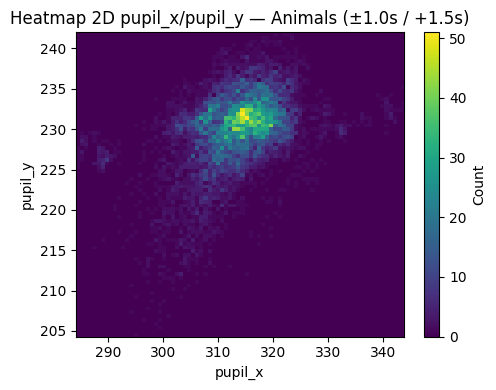

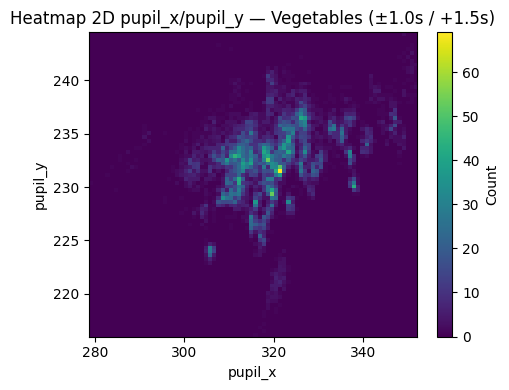

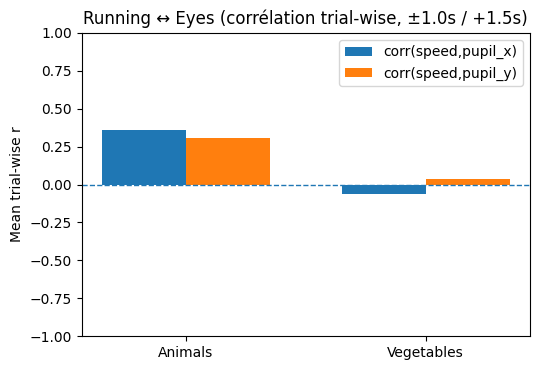

In [91]:
# ==== CELLULE SUIVANTE : HEATMAP (pupil_x/y), BLINK RATE, RUNNING↔EYES ====
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ---------- Paramètres ----------
t_before = 1.0   # fenêtre large demandée
t_after  = 1.5
nbins_2d = 80    # résolution heatmap

# Raccourcis sur les listes d'événements (créées dans ta cellule précédente)
times_animals    = changes_times_list.get("Animals_images", np.array([]))
times_vegetables = changes_times_list.get("Vegetables_images", np.array([]))

# Colonnes (on force l'usage de pupil_x / pupil_y comme tu veux)
xcol, ycol = 'pupil_x', 'pupil_y'

# ---------- Helpers ----------
def collect_eye_in_windows(df_eye, event_times, xcol, ycol, t_before, t_after):
    """Concatène pupil_x/y dans la fenêtre autour de tous les events."""
    xs, ys = [], []
    for t0 in np.asarray(event_times):
        m = (df_eye['timestamps'] >= t0 - t_before) & (df_eye['timestamps'] <= t0 + t_after)
        if not m.any():
            continue
        xs.append(df_eye.loc[m, xcol].values)
        ys.append(df_eye.loc[m, ycol].values)
    if len(xs) == 0:
        return np.array([]), np.array([])
    return np.concatenate(xs), np.concatenate(ys)

def plot_2d_heat(x, y, title, nbins=80):
    """Heatmap 2D robuste (valeurs NaN retirées)."""
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 10:
        plt.figure(figsize=(4.5,3.5))
        plt.title(title); plt.text(0.5, 0.5, "Pas assez de points", ha='center')
        plt.axis('off'); plt.tight_layout(); plt.show()
        return
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    plt.figure(figsize=(5,4))
    plt.imshow(H.T, extent=extent, origin='lower', aspect='auto')  # cmap par défaut
    plt.colorbar(label='Count')
    plt.title(title); plt.xlabel(xcol); plt.ylabel(ycol)
    plt.tight_layout(); plt.show()

def blink_flag_series(df_eye):
    """Retourne une série booléenne blink, même si likely_blink manque."""
    if 'likely_blink' in df_eye.columns:
        b = df_eye['likely_blink'].astype(float).copy()
        # Clamp [0,1] si jamais…
        b = (b > 0.5).astype(float)
        return b
    # Fallback simple: chutes extrêmes de pupil_area ou NaN = blink
    if 'pupil_area' in df_eye.columns:
        area = df_eye['pupil_area'].astype(float).copy()
        thr = np.nanpercentile(area, 1)  # 1% le plus bas
        b = (~np.isfinite(area)) | (area <= thr)
        return b.astype(float)
    # Dernier recours: tout faux
    return pd.Series(0.0, index=df_eye.index)

def blink_rate_around_events(df_eye, event_times, t_before, t_after):
    """Moyenne de blink (fraction) dans la fenêtre autour des events."""
    b = blink_flag_series(df_eye)
    rates = []
    for t0 in np.asarray(event_times):
        m = (df_eye['timestamps'] >= t0 - t_before) & (df_eye['timestamps'] <= t0 + t_after)
        if not m.any():
            continue
        rates.append(np.nanmean(b.loc[m].values.astype(float)))
    return np.nan if len(rates) == 0 else float(np.nanmean(rates))

def safe_corr(a, b):
    """Corrélation robuste (nan-safe, évite divisions par 0)."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    a, b = a[m], b[m]
    if a.size < 3: return np.nan
    a = a - a.mean(); b = b - b.mean()
    sa, sb = a.std(), b.std()
    if sa < 1e-12 or sb < 1e-12: return np.nan
    return np.corrcoef(a/sa, b/sb)[0,1]

def trialwise_running_eye_corr(df_eye, df_run, event_times, xcol, ycol, t_before, t_after):
    """Corrélation moyenne par essai entre speed et pupil_x/pupil_y (barres)."""
    rs_x, rs_y = [], []
    for t0 in np.asarray(event_times):
        m_eye = (df_eye['timestamps'] >= t0 - t_before) & (df_eye['timestamps'] <= t0 + t_after)
        m_run = (df_run['timestamps'] >= t0 - t_before) & (df_run['timestamps'] <= t0 + t_after)
        e_sub = df_eye.loc[m_eye, ['timestamps', xcol, ycol]].copy().sort_values('timestamps')
        r_sub = df_run.loc[m_run, ['timestamps', 'speed']].copy().sort_values('timestamps')
        if e_sub.empty or r_sub.empty:
            continue
        # Alignement temporel approx (asof)
        tmp = pd.merge_asof(r_sub, e_sub, on='timestamps', direction='nearest')
        rs_x.append(safe_corr(tmp['speed'].values, tmp[xcol].values))
        rs_y.append(safe_corr(tmp['speed'].values, tmp[ycol].values))
    return (np.nan if len(rs_x)==0 else float(np.nanmean(rs_x)),
            np.nan if len(rs_y)==0 else float(np.nanmean(rs_y)))

# ---------- (A) HEATMAPS 2D (pupil_x / pupil_y) sur grande fenêtre ----------
X_an, Y_an = collect_eye_in_windows(eye_tracking, times_animals,    xcol, ycol, t_before, t_after)
X_ve, Y_ve = collect_eye_in_windows(eye_tracking, times_vegetables, xcol, ycol, t_before, t_after)

plot_2d_heat(X_an, Y_an, f"Heatmap 2D {xcol}/{ycol} — Animals (±{t_before:.1f}s / +{t_after:.1f}s)", nbins_2d)
plot_2d_heat(X_ve, Y_ve, f"Heatmap 2D {xcol}/{ycol} — Vegetables (±{t_before:.1f}s / +{t_after:.1f}s)", nbins_2d)


# ---------- (C) RUNNING vs EYES : barres de corrélation (pas de scatter) ----------
# Corrélation trial-wise dans la grande fenêtre, pour Animals et Vegetables
rw_ax_an, rw_ay_an = trialwise_running_eye_corr(eye_tracking, running_speed, times_animals,    xcol, ycol, t_before, t_after)
rw_ax_ve, rw_ay_ve = trialwise_running_eye_corr(eye_tracking, running_speed, times_vegetables, xcol, ycol, t_before, t_after)

plt.figure(figsize=(5.5,3.8))
cats = ['Animals', 'Vegetables']
vals_x = [np.nan_to_num(rw_ax_an, nan=0.0), np.nan_to_num(rw_ax_ve, nan=0.0)]
vals_y = [np.nan_to_num(rw_ay_an, nan=0.0), np.nan_to_num(rw_ay_ve, nan=0.0)]
xpos = np.arange(len(cats))
w = 0.35
plt.bar(xpos - w/2, vals_x, width=w, label=f'corr(speed,{xcol})')
plt.bar(xpos + w/2, vals_y, width=w, label=f'corr(speed,{ycol})')
plt.xticks(xpos, cats); plt.ylim(-1, 1)
plt.axhline(0, linestyle='--', linewidth=1)
plt.ylabel('Mean trial-wise r')
plt.title(f'Running ↔ Eyes (corrélation trial-wise, ±{t_before:.1f}s / +{t_after:.1f}s)')
plt.legend()
if any(np.isnan(v) for v in [rw_ax_an, rw_ay_an, rw_ax_ve, rw_ay_ve]):
    plt.text(0.5, 0.92, "Note: corr NaN remplacées par 0 pour affichage", ha='center', transform=plt.gca().transAxes)
plt.tight_layout(); plt.show()


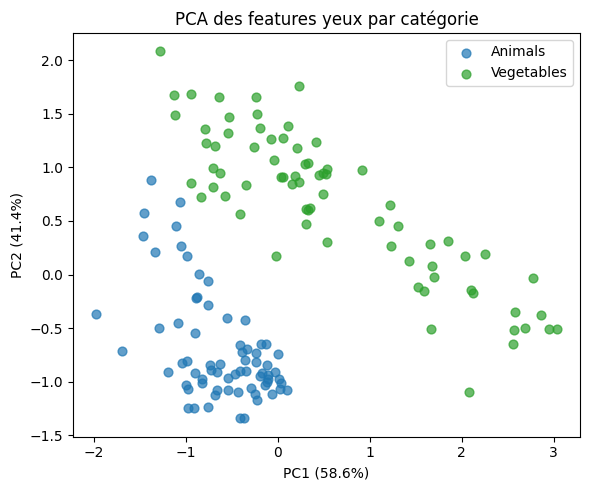

In [92]:
# ==== PCA EYE FEATURES (eye_area, pupil_area, blink count) ====
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Paramètres
t_before, t_after = 0.25, 0.75
features_list = ['eye_area', 'pupil_area', 'likely_blink']

def extract_eye_features(df_eye, event_times, t_before=0.25, t_after=0.75):
    feats = []
    for t0 in np.asarray(event_times):
        m = (df_eye['timestamps'] >= t0 - t_before) & (df_eye['timestamps'] <= t0 + t_after)
        if not m.any(): 
            continue
        sub = df_eye.loc[m, features_list]
        f = {
            'eye_area_mean':   np.nanmean(sub['eye_area'])   if 'eye_area' in sub else np.nan,
            'pupil_area_mean': np.nanmean(sub['pupil_area']) if 'pupil_area' in sub else np.nan,
            'blink_rate':      np.nanmean(sub['likely_blink']) if 'likely_blink' in sub else np.nan,
        }
        feats.append(f)
    return pd.DataFrame(feats)

# --- Récupération par catégorie
df_an = extract_eye_features(eye_tracking, changes_times_list['Animals_images'], t_before, t_after)
df_an['category'] = 'Animals'

df_ve = extract_eye_features(eye_tracking, changes_times_list['Vegetables_images'], t_before, t_after)
df_ve['category'] = 'Vegetables'

df_all = pd.concat([df_an, df_ve], ignore_index=True).dropna()

# --- PCA
X = df_all[['eye_area_mean','pupil_area_mean','blink_rate']].values
Xz = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xz)

# --- Plot
plt.figure(figsize=(6,5))
for cat, col in zip(['Animals','Vegetables'], ['tab:blue','tab:green']):
    m = df_all['category']==cat
    plt.scatter(Z[m,0], Z[m,1], s=40, alpha=0.7, label=cat, c=col)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA des features yeux par catégorie")
plt.legend()
plt.tight_layout()
plt.show()


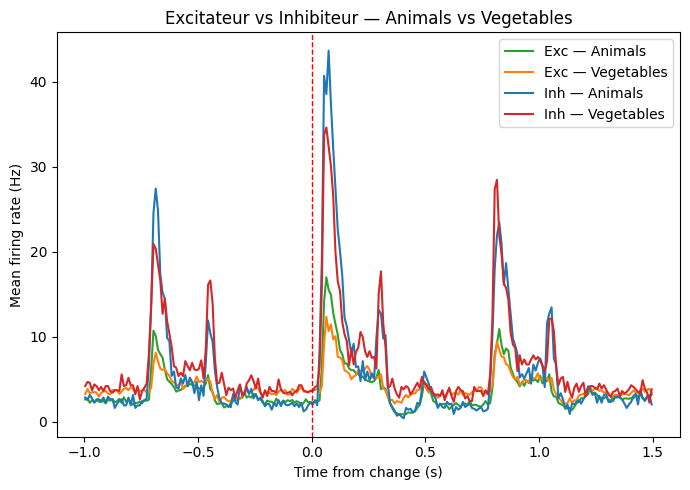

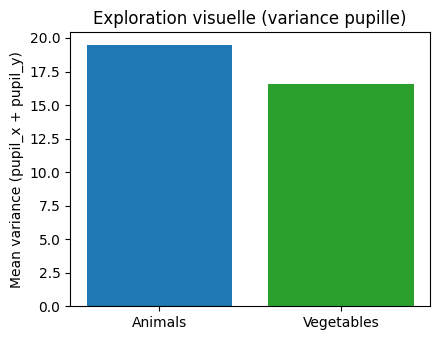

In [ ]:
# ==== CELLULE : Excitateur vs Inhibiteur + Variance Pupille ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- (A) Excitateur vs Inhibiteur ----------
# Heuristique classique Allen : spike large = excitateur, court = inhibiteur
thr_duration = 0.45  # ms, à ajuster si besoin
exc_units = good_units[(good_units['waveform_duration'] >= thr_duration)]
inh_units = good_units[(good_units['waveform_duration'] <  thr_duration)]

def mean_resp_per_group(units, ctimes, bin_ephys=0.01, t_before=1, duration=2.5):
    """Retourne la moyenne populationnelle alignée aux events."""
    all_resps = []
    for iu, unit in units.iterrows():
        spikes = spike_times[iu]
        resp, bins = makePSTH(spikes, ctimes - t_before, duration, binSize=bin_ephys)
        all_resps.append(resp)
    if not all_resps: 
        return None, None
    all_resps = np.array(all_resps)
    bin_centers = bins[:-1] + bin_ephys/2 - t_before
    return bin_centers, all_resps.mean(0)

# Réponses moyennes excitateur/inhibiteur pour Animaux vs Végétaux
ct_an = changes_times_list.get("Animals_images", np.array([]))
ct_ve = changes_times_list.get("Vegetables_images", np.array([]))

bin_exc_an, resp_exc_an = mean_resp_per_group(exc_units, ct_an)
bin_exc_ve, resp_exc_ve = mean_resp_per_group(exc_units, ct_ve)
bin_inh_an, resp_inh_an = mean_resp_per_group(inh_units, ct_an)
bin_inh_ve, resp_inh_ve = mean_resp_per_group(inh_units, ct_ve)

plt.figure(figsize=(7,5))
if resp_exc_an is not None:
    plt.plot(bin_exc_an, resp_exc_an, label="Exc — Animals", color="tab:green")
    plt.plot(bin_exc_ve, resp_exc_ve, label="Exc — Vegetables", color="tab:orange")
if resp_inh_an is not None:
    plt.plot(bin_inh_an, resp_inh_an,  label="Inh — Animals", color="tab:blue")
    plt.plot(bin_inh_ve, resp_inh_ve,  label="Inh — Vegetables", color="tab:red")
plt.axvline(0, color="red", linestyle="--", lw=1)
plt.xlabel("Time from change (s)"); plt.ylabel("Mean firing rate (Hz)")
plt.title("Excitateur vs Inhibiteur — Animals vs Vegetables")
plt.legend(); plt.tight_layout(); plt.show()



